In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error
from xgboost import XGBRegressor

In [2]:
df=pd.read_csv("Housing.csv")

In [3]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [4]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.duplicated().sum()

0

In [7]:
df["mainroad"]=df["mainroad"].map({"yes":1,"no":0})
df["guestroom"]=df["guestroom"].map({"yes":1,"no":0})
df["basement"]=df["basement"].map({"yes":1,"no":0})
df["hotwaterheating"]=df["hotwaterheating"].map({"yes":1,"no":0})
df["airconditioning"]=df["airconditioning"].map({"yes":1,"no":0})
df["prefarea"]=df["prefarea"].map({"yes":1,"no":0})

In [8]:
df["furnishingstatus"].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [9]:
df=pd.get_dummies(df,columns=["furnishingstatus"])
df = df.astype(int)

In [10]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


In [11]:
X=df.drop("price",axis=1)
Y = np.log(df["price"])

In [12]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [13]:
Y_train

46     15.833741
93     15.656060
335    15.181602
412    15.048071
471    14.917451
         ...    
71     15.725794
106    15.633587
270    15.283385
435    15.006398
102    15.639253
Name: price, Length: 436, dtype: float64

In [14]:
scaler=StandardScaler()

In [15]:
X_train["area"]=scaler.fit_transform(X_train[['area']])
X_test["area"]=scaler.transform(X_test[["area"]])

In [16]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,0.384168,3,2,4,1,0,0,0,1,1,0,1,0,0
93,0.929181,3,2,1,1,0,1,0,1,3,0,0,1,0
335,-0.607755,2,1,1,1,0,1,0,1,2,0,1,0,0
412,-1.155492,3,1,2,1,0,1,0,0,0,1,0,0,1
471,-0.637730,3,1,2,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.384168,4,2,4,1,0,0,0,1,0,0,0,0,1
106,0.134371,4,2,1,1,0,1,0,1,0,1,0,1,0
270,-0.297097,3,2,3,1,0,0,1,0,1,0,1,0,0
435,-0.506019,2,1,1,1,0,0,0,0,0,0,0,0,1


In [17]:
model=LinearRegression()

In [18]:
model.fit(X_train,Y_train)

LinearRegression()

In [19]:
y_predict=model.predict(X_test)

In [20]:
print(f"R2 score is: {r2_score(Y_test,y_predict)}")
print(f"Mean square error is: {mean_squared_error(Y_test,y_predict)}")
print(f"Mean absolute error is: {mean_absolute_error(Y_test,y_predict)}")
print(f"Mean absolute error is: {root_mean_squared_error(Y_test,y_predict)}")

R2 score is: 0.6722047299637574
Mean square error is: 0.06329357331376184
Mean absolute error is: 0.19990272792834857
Mean absolute error is: 0.2515821402917183


In [21]:
original_predicted_value=np.exp(y_predict)
Y_test_original = np.exp(Y_test)

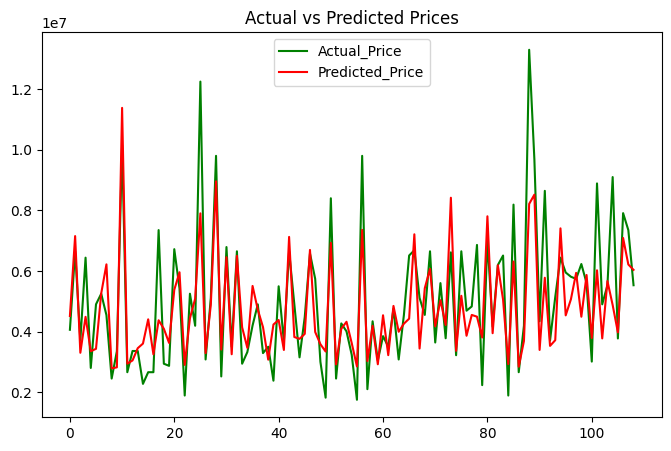

In [22]:
plt.figure(figsize=(8,5))
plt.plot(Y_test_original.values,label="Actual_Price",color="green")
plt.plot(original_predicted_value,label="Predicted_Price",color="red")

plt.title('Actual vs Predicted Prices')
plt.legend()
plt.show()

In [23]:
model1 = XGBRegressor(
    random_state=42,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8
)

In [24]:
model1.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [25]:
y_predict1 = model1.predict(X_test)

In [26]:
print(f"R2 score is: {r2_score(Y_test,y_predict1)}")
print(f"Mean square error is: {mean_squared_error(Y_test,y_predict1)}")
print(f"Mean absolute error is: {mean_absolute_error(Y_test,y_predict1)}")
print(f"Mean absolute error is: {root_mean_squared_error(Y_test,y_predict)}")

R2 score is: 0.6547499125054776
Mean square error is: 0.06666390189828293
Mean absolute error is: 0.20595027222774565
Mean absolute error is: 0.2515821402917183


In [27]:
original_predicted_value_model1=np.exp(y_predict1)
Y_test_original_model1 = np.exp(Y_test)

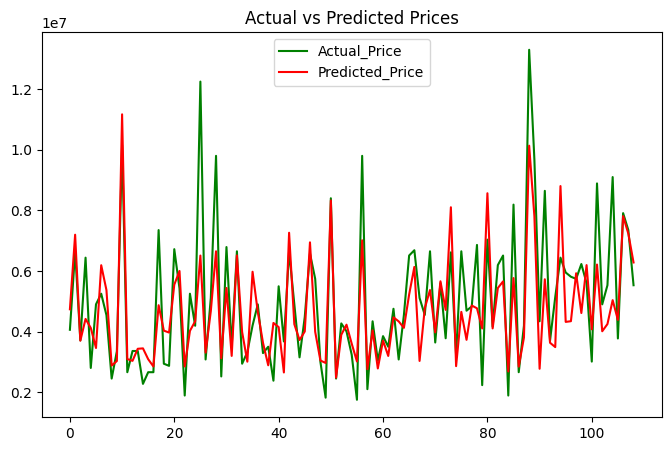

In [28]:
plt.figure(figsize=(8,5))
plt.plot(Y_test_original_model1.values,label="Actual_Price",color="green")
plt.plot(original_predicted_value_model1,label="Predicted_Price",color="red")

plt.title('Actual vs Predicted Prices')
plt.legend()
plt.show()